# H&E image-feature clustering into 24 structures

This second notebook converts the HIPT feature field into coherent
histology-derived spatial structures. It reproduces the H&E branch validated
in `test0730/he_rep1`: 30 initial tissue clusters are consolidated by
feature-based merging, bilateral symmetry, and spatial cleanup into 24 final
regions. These labels are derived from the image only.

## Inputs from notebook 1

Run the image-feature notebook first. Its default outputs are
`tutorials/cross_modality/histology/output/feature_extraction/he.jpg` and
`embeddings-hist-vit.pickle`. During documentation validation, explicit image,
feature, or completed clustering-stage paths can be supplied with environment
variables; public users do not need those variables.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_DATA_DIR",
        PROJECT_ROOT / "data" / "cross_modality" / "histology" / "mouse_brain",
    )
).expanduser()
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "histology" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
FEATURE_DIR = OUTPUT_DIR / "feature_extraction"
IMAGE_PATH = Path(
    os.environ.get("SPALIGNDE_HISTOLOGY_IMAGE", FEATURE_DIR / "he.jpg")
).expanduser()
FEATURE_PATH = Path(
    os.environ.get(
        "SPALIGNDE_DOCUMENTATION_FEATURE_PATH",
        FEATURE_DIR / "embeddings-hist-vit.pickle",
    )
).expanduser()
CLUSTER_DIR = OUTPUT_DIR / "histology_clustering"

features = spAlignDE.load_histology_features(IMAGE_PATH, FEATURE_PATH)
print("Image:", features.prepared_image_path.name)
print("Feature field:", features.feature_path.name)
print("Feature grid:", features.feature_grid_shape_hw)

Image: he.jpg
Feature field: embeddings-hist-vit.pickle
Feature grid: (1288, 980)


## Cluster, merge, and spatially clean image features

The executable pipeline is deliberately staged so each decision can be audited:

1. **Tissue/background mask:** cluster the feature grid into two broad groups,
   use image brightness to identify slide background, and retain the main tissue
   support.
2. **Feature assembly:** standardize the HIPT context (`cls`), local (`sub`),
   and RGB blocks separately; apply `rgb_weight=0.25`; append normalized x/y
   coordinates with `coordinate_weight=0.05`.
3. **Initial tissue partition:** deterministic K-means assigns the tissue pixels
   to 30 image-feature clusters (`random_state=0`).
4. **Hole filling and feature merging:** fill internal unlabeled holes and merge
   feature-similar regions using their standardized feature centroids.
5. **Layout-aware symmetry merging:** accept at most two additional merges only
   when reflection overlap, feature cosine similarity, centroid distance, and
   the global symmetry-score gain all pass their gates.
6. **Spatial cleanup:** remove disconnected islands smaller than 250 feature-grid
   pixels and relabel the final structures compactly; background stays −1.

### Image orientation and the symmetry axis

The prepared benchmark image contains **two coronal sections stacked
vertically**, and it is displayed exactly as stored with `origin="upper"`.
Therefore the paper profile uses `symmetry_axis="ud"`: it compares corresponding
image features between the upper and lower sections. It does **not** assume that
one brain section is anatomically symmetric across its dorsal–ventral axis.

For a single upright coronal section whose two hemispheres are arranged
left-to-right, use `symmetry_axis="lr"`. If the input has been rotated, first set
the axis from the prepared `he.jpg`, not from the original scanner orientation.
Partial, strongly asymmetric, or pathological tissue should not inherit the
benchmark symmetry setting without reviewing the reflected-mask candidates.


In [3]:
cluster_config = spAlignDE.HistologyClusteringConfig(
    background_clusters=2,
    image_clusters=30,
    merged_clusters=30,
    rgb_weight=0.25,
    coordinate_weight=0.05,
    cleanup_min_size=250,
    symmetry_axis="ud",  # two benchmark sections are stacked top-to-bottom
    symmetry_max_merges=2,
    random_state=0,
)

completed_stage = os.environ.get("SPALIGNDE_DOCUMENTATION_CLUSTER_DIR")
if completed_stage:
    histology = spAlignDE.load_histology_clustering(completed_stage)
    execution_mode = "validated clustering-stage output"
else:
    histology = spAlignDE.cluster_histology_features(
        features,
        CLUSTER_DIR,
        config=cluster_config,
    )
    execution_mode = "fresh package clustering"

display(
    pd.Series(
        {
            "mode": execution_mode,
            "feature grid (height, width)": histology.shape,
            "tissue pixels": int(histology.tissue_mask.sum()),
            "initial regions": int(histology.summary["regions"]["labels_full_raw"]),
            "final cleaned regions": histology.n_structures,
            "symmetry axis": cluster_config.symmetry_axis,
            "maximum symmetry merges": cluster_config.symmetry_max_merges,
        },
        name="value",
    ).to_frame()
)

,value
mode,validated clustering-stage output
"feature grid (height, width)","(1288, 980)"
tissue pixels,720100
initial regions,30
final cleaned regions,24
symmetry axis,ud
maximum symmetry merges,2


### How to adapt image-feature clustering

Tune one stage at a time and keep all upstream outputs fixed while comparing QC
panels:

- Start with the prepared image orientation and tissue mask. An incorrect tissue
  mask cannot be repaired by increasing the number of clusters.
- `image_clusters` controls initial tissue granularity. Increase it when distinct
  morphology is merged; decrease it when one anatomical field fragments into
  many visually indistinguishable regions.
- `rgb_weight` increases stain/color influence. Reduce it when clusters follow
  illumination or staining artifacts rather than morphology.
- `coordinate_weight` promotes spatial compactness. Reduce it when identical
  morphology is split merely because it occurs in different locations.
- Choose `symmetry_axis="ud"` only for vertically stacked repeated sections, and
  `"lr"` for a single upright bilateral section. Inspect candidate reflected
  regions before accepting any symmetry-driven merge.
- `symmetry_max_merges` limits the number of post-merges; the paper permits two.
  Raising it can erase real asymmetry, while lowering it retains more independent
  image regions.
- `cleanup_min_size` is measured in 16-pixel feature-grid units and must be
  reconsidered whenever image resolution, feature stride, or tissue size changes.

Choose parameters from the complete image-to-label evidence chain. The final
number of structures is an output, not a target that should be forced without
morphological and feature support.


## Quality control: image to final structures

The four panels preserve the prepared image's upper-origin orientation and show
the evidence chain used in Supplementary Figure 8: original H&E morphology,
30 initial feature assignments, layout-aware symmetry merging, and the cleaned
24-region structure map. Colors identify image structures only; they do not
represent cell types or atlas labels. Before proceeding, confirm that left/right
or upper/lower counterparts were merged only when that symmetry matches the
actual prepared-image layout.


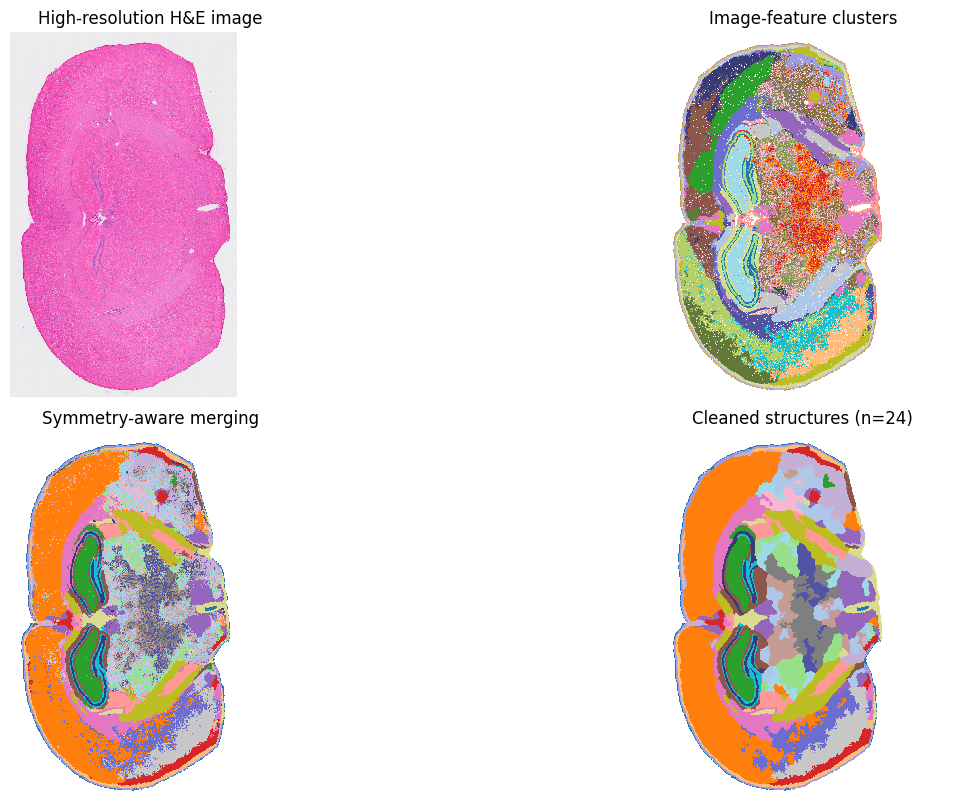

In [4]:
fig, axes = spAlignDE.plot_histology_feature_clusters(
    histology,
    figsize=(13, 8),
)
fig.savefig(FIGURE_DIR / "he_feature_clustering_24_structures.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "he_feature_clustering_24_structures.svg", bbox_inches="tight")
plt.show()

## Output contract and next step

The compact result stores the tissue mask and raw, merged, and cleaned integer
label rasters at feature-grid resolution. Continue with **Xenium Replicate 1
to H&E — pre-alignment and S-LDDMM**. The clustering output is the fixed image
reference for that notebook.